In [1]:
import numpy as np
import sklearn
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

housing = fetch_california_housing()
import tensorflow as tf

In [2]:
import os

os.environ["KERAS_TELEMETRY"] = "0"

In [3]:
housing.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [4]:
X, y = housing.data, housing.target

In [5]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [6]:
X = pd.DataFrame(X, columns=housing.feature_names)

In [7]:
y = pd.DataFrame(y, columns=housing.target_names)

In [8]:
X.shape

(20640, 8)

In [9]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [10]:
y

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42
)

In [12]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6192 entries, 18474 to 15795
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      6192 non-null   float64
 1   HouseAge    6192 non-null   float64
 2   AveRooms    6192 non-null   float64
 3   AveBedrms   6192 non-null   float64
 4   Population  6192 non-null   float64
 5   AveOccup    6192 non-null   float64
 6   Latitude    6192 non-null   float64
 7   Longitude   6192 non-null   float64
dtypes: float64(8)
memory usage: 435.4 KB


In [13]:
def display_info(df):
    display(df)
    print("\n")
    display(df.info())

In [14]:
display_info(X_train)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
18474,3.8788,20.0,5.140069,1.060850,2656.0,3.049369,37.13,-121.66
1203,2.3243,27.0,6.347188,1.063570,1100.0,2.689487,39.38,-121.74
6413,6.5722,34.0,6.194323,1.004367,1344.0,2.934498,34.11,-118.03
17074,2.9286,20.0,2.337963,1.000000,326.0,1.509259,37.48,-122.21
616,3.9500,52.0,6.060870,0.969565,545.0,2.369565,37.74,-122.15
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96




<class 'pandas.core.frame.DataFrame'>
Index: 6192 entries, 18474 to 15795
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      6192 non-null   float64
 1   HouseAge    6192 non-null   float64
 2   AveRooms    6192 non-null   float64
 3   AveBedrms   6192 non-null   float64
 4   Population  6192 non-null   float64
 5   AveOccup    6192 non-null   float64
 6   Latitude    6192 non-null   float64
 7   Longitude   6192 non-null   float64
dtypes: float64(8)
memory usage: 435.4 KB


None

In [15]:
X_train.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,6192.000000,6192.000000,6192.000000,6192.000000,6192.000000,6192.000000,6192.000000,6192.000000
mean,3.869097,28.532784,5.467948,1.104396,1440.228036,3.009381,35.671841,-119.592959
std,1.911034,12.542773,2.882747,0.521006,1178.533145,6.410445,2.144273,2.011730
min,0.499900,2.000000,0.888889,0.500000,3.000000,0.692308,32.550000,-124.300000
25%,2.562500,18.000000,4.469664,1.007350,793.000000,2.434894,33.940000,-121.810000
50%,3.528300,29.000000,5.231174,1.050626,1174.000000,2.825156,34.270000,-118.530000
75%,4.729575,37.000000,6.071763,1.100000,1740.250000,3.264210,37.730000,-118.010000
max,15.000100,52.000000,141.909091,25.636364,35682.000000,502.461538,41.950000,-114.470000


In [16]:
norm_layer = layers.Normalization(axis=-1)

In [17]:
norm_layer.adapt(X_train.values)

In [20]:
X_train.values

array([[   3.8788    ,   20.        ,    5.14006889, ...,    3.04936854,
          37.13      , -121.66      ],
       [   2.3243    ,   27.        ,    6.34718826, ...,    2.68948655,
          39.38      , -121.74      ],
       [   6.5722    ,   34.        ,    6.19432314, ...,    2.93449782,
          34.11      , -118.03      ],
       ...,
       [   2.9344    ,   36.        ,    3.98671727, ...,    3.33206831,
          34.03      , -118.38      ],
       [   5.7192    ,   15.        ,    6.39534884, ...,    3.17889088,
          37.58      , -121.96      ],
       [   2.5755    ,   52.        ,    3.40257649, ...,    2.10869565,
          37.77      , -122.42      ]])

In [21]:
model = models.Sequential(
    [
        layers.Input((X_train.shape[1],)),
        norm_layer,
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1),
    ]
)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,818 (18.82 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 17 (72.00 B)

In [41]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.losses.MSE,
    metrics=[tf.losses.MAE],
)

In [42]:
import tqdm

model.fit(
    X_train.values,
    y_train.values,
    epochs=60,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/60
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 644us/step - loss: 0.2291 - mean_absolute_error: 0.3294 - val_loss: 0.3038 - val_mean_absolute_error: 0.3857
Epoch 2/60
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step - loss: 0.2255 - mean_absolute_error: 0.3268 - val_loss: 0.3068 - val_mean_absolute_error: 0.3898
Epoch 3/60
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 384us/step - loss: 0.2249 - mean_absolute_error: 0.3280 - val_loss: 0.3032 - val_mean_absolute_error: 0.3809
Epoch 4/60
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 417us/step - loss: 0.2239 - mean_absolute_error: 0.3263 - val_loss: 0.3056 - val_mean_absolute_error: 0.3787
Epoch 5/60
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 375us/step - loss: 0.2241 - mean_absolute_error: 0.3256 - val_loss: 0.3026 - val_mean_absolute_error: 0.3816
Epoch 6/60
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 381us/step - loss: 0.2233 - mean_absolute_error: 0.3260 - val_loss: 0.3050 - val_mean_absolute_error: 0.3797
Epoch 7/60
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 378us/step - loss: 0.2231 - mean_absolute_err

In [43]:
h = model.history.history

In [44]:
type(h)

dict

In [45]:
[(x, y) for x, y in zip(h.keys(), h.values())]

[('loss',
  [0.229096457362175,
   0.22553007304668427,
   0.22490842640399933,
   0.22386085987091064,
   0.22413459420204163,
   0.22332054376602173,
   0.22311894595623016,
   0.22267697751522064,
   0.22272944450378418,
   0.22231951355934143,
   0.2223152220249176,
   0.2216966450214386,
   0.22187700867652893,
   0.22109262645244598,
   0.22143042087554932,
   0.22120390832424164,
   0.22060894966125488,
   0.220694899559021,
   0.22073079645633698,
   0.2202570140361786,
   0.22033530473709106,
   0.22002331912517548,
   0.22011986374855042,
   0.21988587081432343,
   0.2197851687669754,
   0.21965138614177704,
   0.2192971408367157,
   0.21908512711524963,
   0.21910223364830017,
   0.2190614938735962,
   0.21842007339000702,
   0.2183077037334442,
   0.21828150749206543,
   0.21840187907218933,
   0.2178548127412796,
   0.21789999306201935,
   0.2178279310464859,
   0.21770130097866058,
   0.21763655543327332,
   0.21794205904006958,
   0.21696698665618896,
   0.21721614897251

In [49]:
out = pd.DataFrame.from_dict(model.history.history)
out = pd.DataFrame(model.history.history)
out

,loss,mean_absolute_error,val_loss,val_mean_absolute_error
0,0.229096,0.329440,0.303806,0.385723
1,0.225530,0.326820,0.306848,0.389774
2,0.224908,0.328032,0.303196,0.380884
3,0.223861,0.326271,0.305573,0.378673
4,0.224135,0.325564,0.302574,0.381550
5,0.223321,0.326026,0.304953,0.379707
6,0.223119,0.325478,0.303762,0.380243
7,0.222677,0.325130,0.306400,0.385974
8,0.222729,0.324835,0.304254,0.384823
9,0.222320,0.325256,0.303298,0.384007


In [50]:
out.describe()

,loss,mean_absolute_error,val_loss,val_mean_absolute_error
count,60.000000,60.000000,60.000000,60.000000
mean,0.219160,0.323104,0.304405,0.383197
std,0.003094,0.002002,0.000960,0.002771
min,0.214672,0.319676,0.302299,0.378673
25%,0.216524,0.321572,0.303756,0.381259
50%,0.218741,0.322975,0.304284,0.382977
75%,0.221120,0.324331,0.305037,0.384857
max,0.229096,0.329440,0.306848,0.392308


In [51]:
mae = model.evaluate(X_test.values, y_test.values, verbose=1, return_dict=True)

452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 217us/step - loss: 0.2942 - mean_absolute_error: 0.3654


In [57]:
X_test_predicted = model.predict(X_test.values)

452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 153us/step


In [61]:
y_test_predicted = model.predict(y_test.values)

452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 150us/step


In [85]:
y_test_predicted = y_test_predicted[:, 0]

In [87]:
y_test_predicted.shape

(14448,)

In [91]:
def los

0       -16.192759
1       -16.203573
2       -13.231166
3       -15.016875
4       -14.451255
           ...    
14443   -16.077234
14444   -16.133574
14445   -14.801677
14446   -15.883426
14447   -15.857472
Length: 14448, dtype: float32

In [33]:
model._tracker.config

{'trainable_variables': (<function keras.src.layers.layer.Layer._initialize_tracker.<locals>.<lambda>(x)>,
  []),
 'non_trainable_variables': (<function keras.src.layers.layer.Layer._initialize_tracker.<locals>.<lambda>(x)>,
  []),
 'metrics': (<function keras.src.layers.layer.Layer._initialize_tracker.<locals>.<lambda>(x)>,
  []),
 'layers': (<function keras.src.layers.layer.Layer._initialize_tracker.<locals>.<lambda>(x)>,
  [<InputLayer name=input_layer, built=True>,
   <Normalization name=normalization, built=True>,
   <Dense name=dense, built=True>,
   <Dense name=dense_1, built=True>,
   <Dense name=dense_2, built=True>,
   <Functional name=functional, built=True>]),
 'seed_generators': (<function keras.src.layers.layer.Layer._initialize_tracker.<locals>.<lambda>(x)>,
  [])}

In [34]:
model.compiled_metrics

<keras.src.backend.tensorflow.trainer.TensorFlowTrainer.compiled_metrics.<locals>.DeprecatedCompiledMetric at 0x1617a12e0>

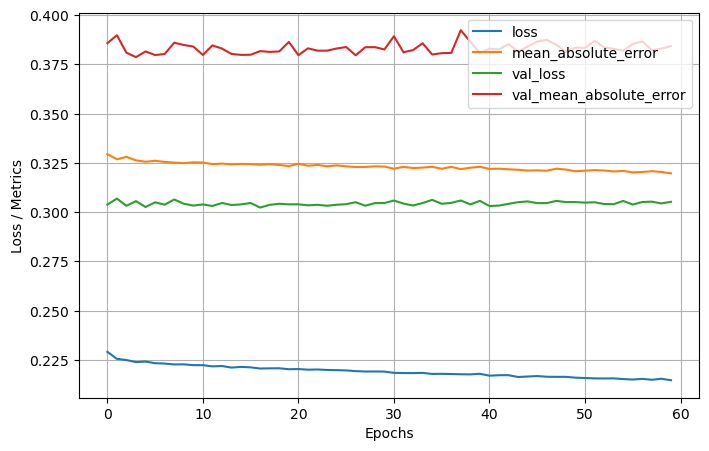

In [54]:
import matplotlib.pyplot as plt

out.plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss / Metrics")


plt.show()

In [36]:
for var in model.optimizer.variables:
    print(f"Moment Name: {var.name}, Shape: {var.shape}")

Moment Name: iteration, Shape: ()
Moment Name: learning_rate, Shape: ()
Moment Name: sequential_dense_kernel_momentum, Shape: (8, 64)
Moment Name: sequential_dense_kernel_velocity, Shape: (8, 64)
Moment Name: sequential_dense_bias_momentum, Shape: (64,)
Moment Name: sequential_dense_bias_velocity, Shape: (64,)
Moment Name: sequential_dense_1_kernel_momentum, Shape: (64, 64)
Moment Name: sequential_dense_1_kernel_velocity, Shape: (64, 64)
Moment Name: sequential_dense_1_bias_momentum, Shape: (64,)
Moment Name: sequential_dense_1_bias_velocity, Shape: (64,)
Moment Name: sequential_dense_2_kernel_momentum, Shape: (64, 1)
Moment Name: sequential_dense_2_kernel_velocity, Shape: (64, 1)
Moment Name: sequential_dense_2_bias_momentum, Shape: (1,)
Moment Name: sequential_dense_2_bias_velocity, Shape: (1,)


In [37]:
dir(model.optimizer)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_trackable_child',
 '_add_variable_with_custom_getter',
 '_all_reduce_sum_gradients',
 '_api_export_path',
 '_api_export_symbol_id',
 '_apply_weight_decay',
 '_backend_apply_gradients',
 '_backend_increment_gradient_accumulators',
 '_backend_reset_gradient_accumulators',
 '_backend_update_step',
 '_check_super_called',
 '_check_variables_are_known',
 '_checkpoint_adapter',
 '_checkpoint_dependencies',
 '_clip_by_norm',
 '_clip_gradients',
 '_copy_trackable_to_cpu',
 '_deferred_dependencies',
 '_delete_tracking',
 '_deserialization_dependencies',
 '_deserialize_from_proto',
 '_dist

In [38]:
type(model.optimizer)

keras.src.optimizers.adam.Adam

0.9

In [92]:
model.optimizer.get_config()

{'name': 'adam',
 'learning_rate': 9.999999747378752e-05,
 'weight_decay': None,
 'clipnorm': None,
 'global_clipnorm': None,
 'clipvalue': None,
 'use_ema': False,
 'ema_momentum': 0.99,
 'ema_overwrite_frequency': None,
 'loss_scale_factor': None,
 'gradient_accumulation_steps': None,
 'beta_1': 0.9,
 'beta_2': 0.999,
 'epsilon': 1e-07,
 'amsgrad': False}